PROJECT DESCRIPTION : 

Developed a sentiment analysis tool using VADER and RoBERTa to classify reviews as positive, neutral, or negative. Combined rule-based and transformer models for higher accuracy and visualized sentiment trends across large datasets.

SKILLS INVOLVED : Natural Language Processing (NLP), Text Preprocessing and Tokenization, Transformer Models (RoBERTa), Rule-Based Sentiment Analysis (VADER), Data Analysis and Cleaning (Pandas), Data Visualization (Matplotlib, Seaborn), Model Inference with Hugging Face Transformers, Error Handling and Iterative Data Processing, Exploratory Data Analysis (EDA), Python Programming

FRAMEWORKS AND LIBRARIES USED : transformers (Hugging Face), pandas (for data manipulation), matplotlib and seaborn (for visualizations), nltk (for VADER and token processing), scipy.special (for softmax computation), tqdm (for progress tracking in loops), PyTorch (as the backend for transformer models)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk
# nltk.download('maxent_ne_chunker')
# nltk.download('words')

In [ ]:
# Read in data
df = pd.read_csv(r"C:\Users\LAVANYA\OneDrive\Documents\SA\Reviews.csv.zip")
print(df.shape)
df = df.head(500) # We are taking only data of 500 rows
print(df.shape)

In [7]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## QUICK EDA

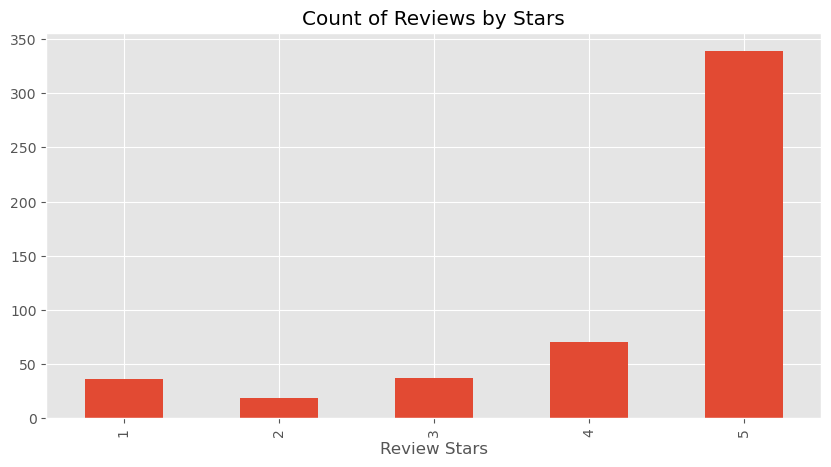

In [8]:
ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

In [9]:
# BASIC NLTK
example = df['Text'][50]
print(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


In [10]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

In [41]:
# PART OF SPEECH  --> GIVES EACH WORD IT'S PART OF SPEECH i.e. TO WHICH PART OF SPEECH IT BELONGS TO
# FOR EX : NN = NOUN, SINGULAR (cat, tree)

tagged = nltk.pos_tag(tokens)
tagged[:10]

[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [12]:
# nltk.download('maxent_ne_chunker')
# nltk.download('words')

# This is from the NLTK (Natural Language Toolkit) library, and it's used for Named Entity Recognition (NER) 
# — that is, finding real-world objects like names of people, places, organizations, etc., in text.

entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

[nltk_data] Downloading package maxent_ne_chunker to C:\Users\Muskan
[nltk_data]     yadav\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to C:\Users\Muskan
[nltk_data]     yadav\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


In [45]:
# ne_chunk(tagged):

# -Takes a list of POS-tagged tokens (like [('Barack', 'NNP'), ('Obama', 'NNP')])
# -Returns a tree-like structure containing named entity subtrees
# -Identifies entities like PERSON, ORGANIZATION, GPE (geo-political entities), etc.

# print vs pprint (Pretty Print)
# 🔸 print:
# -Just prints raw output as-is.
# -Useful for small/simple outputs.

# 🔸 pprint (from pprint module or nltk):
# -Stands for pretty-print
# -Makes complex or nested data structures (like lists, dictionaries, or nltk.Tree) easier to read
# -Adds indentation, line breaks, and formatting

## STEP 1. VADER Sentiment Scoring

VADER --> (Valence Aware Dictionary and sEntiment Reasoner) - Bag of words approach 

We will use NLTK's SentimentIntensityAnalyzer to get the neg/neu/pos scores of the text.

This uses a "bag of words" approach:
1. Stop words are removed
2. each word is scored and combined to a total score.

This approach doesn't accounts for relationship between words, which is an important part of human speech

In [13]:
# nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# tqdm is a Python library that adds smart progress bars to your loops or iterable processing — useful for long operations like:
# -Training models
# -Downloading files
# -Processing large datasets

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to C:\Users\Muskan
[nltk_data]     yadav\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [14]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [15]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [16]:
sia.polarity_scores(example)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [44]:
# Run the polarity score on the entire dataset

# for i, row in tqdm(df.iterrows(), total=len(df)):
# This is a loop over each row in the DataFrame df, using .iterrows(), which returns an index (i) and a row (row) for each row.

# Wrapped with tqdm() to show a progress bar as the loop processes.

# total=len(df) helps tqdm know how many rows there are for accurate progress tracking.


res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [46]:
# 1. vaders = pd.DataFrame(res).T
# - pd.DataFrame(res) → Creates a DataFrame from the res dictionary, where:
# - Columns = 'neg', 'neu', 'pos', 'compound'
# - Index = IDs (like 1001, 1002)

# - .T → Transposes the DataFrame so that:
#     Each row = one review
#     The original keys (res[myid]) become the DataFrame index

# 2. vaders = vaders.reset_index().rename(columns={'index': 'Id'})
# - reset_index() → Moves the index (the review ID) into a regular column
# - rename(...) → Renames that new column from 'index' to 'Id'

# 3. vaders = vaders.merge(df, how='left')
# - Merges the sentiment scores (vaders) with your original DataFrame df (which contains columns like Id, Text, Score, etc.)
# - how='left' → Keep all rows from vaders and attach matching columns from df based on 'Id'

# Resulting DataFrame contains:
# - The original review info (Text, Score, etc.)
# - The VADER sentiment scores (neg, neu, pos, compound)


In [18]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')

In [19]:
# Now we have sentiment score and metadata
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Plot VADER results

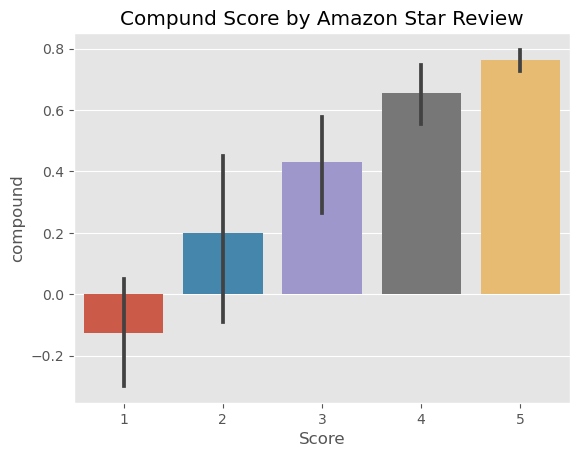

In [20]:
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

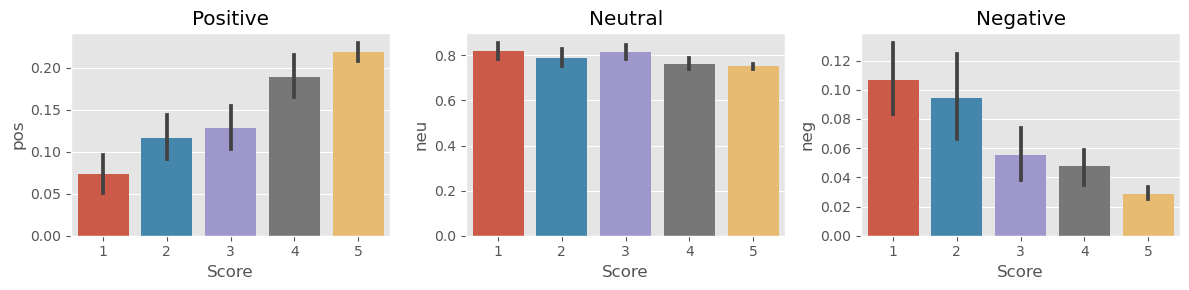

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

# - This creates 1 row and 3 columns of subplots using matplotlib.
# - fig is the entire figure.
# - axs is a list-like object containing 3 individual axes (subplot areas)

sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout() # Adjusts spacing between subplots automatically so labels and titles don't overlap.
plt.show()

## STEP 2. ROBERTA PRETRAINED MODEL 

Use a model trained of a large corpus of data.
Transformer model accounts for the words but also the context related to other words.

In [22]:
!pip install torch transformers scipy

# torch – backend for Hugging Face models
# transformers – to load pretrained models
# scipy – for the softmax function

In [23]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
# from transformers import AutoTokenizer
# - Purpose: Loads a tokenizer for a pre-trained language model.
# Why it's needed:
# - Text must be converted into numerical format (tokens and IDs) before a model can process it.
# - AutoTokenizer figures out which tokenizer to use based on the model you specify.

# from transformers import AutoModelForSequenceClassification
# - Purpose: Loads a pre-trained transformer model (like BERT, RoBERTa, etc.) for text classification tasks.
# Why it's needed:
# - It handles the actual sentiment prediction or other classification tasks (spam detection, emotion detection, etc.).
# - Automatically adds a classification layer on top of the base model.

# from scipy.special import softmax
# - Purpose: Converts raw model output (logits) into probabilities.
# Why it's needed:
# - The model outputs unnormalized scores ("logits"). softmax() transforms them into a probability distribution over classes 
# (e.g., Negative, Neutral, Positive).

In [4]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

C:\Anaconda\Lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


C:\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:133: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Muskan yadav\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [ ]:
# This particular model:
# - Is based on RoBERTa, a powerful transformer-based language model.
# - Was fine-tuned on Twitter data for sentiment classification.
# - Classifies text into 3 labels:
#     0: Negative
#     1: Neutral
#     2: Positive

# tokenizer = AutoTokenizer.from_pretrained(MODEL)
# - This line loads the tokenizer associated with the model.
# - A tokenizer:
#     1. Splits text into tokens
#     2. Converts those tokens into numerical IDs
#     3. Prepares inputs in a format the model understands
    
# model = AutoModelForSequenceClassification.from_pretrained(MODEL)
# - This loads the actual model for sequence classification, meaning it:
#     1. Takes input text (via token IDs)
#     2. Processes it through the transformer layers
#     3. Outputs logits (raw prediction scores) for each class (negative, neutral, positive

In [24]:
# VADER results on example
print(example)
sia.polarity_scores(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [25]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': 0.97635514, 'roberta_neu': 0.020687465, 'roberta_pos': 0.0029573692}


In [ ]:
# encoded_text = tokenizer(example, return_tensors='pt')
# - Takes a sentence (in example, like "I love this!")
# - Converts it into token IDs + attention mask
# - return_tensors='pt' gives output in PyTorch tensor format (required by the model)

# output = model(**encoded_text)
# - Feeds the tokenized input into the sentiment model
# - Returns output.logits — raw scores for each sentiment class (Negative, Neutral, Positive)

# scores = output[0][0].detach().numpy()
# - output[0] gets the logits tensor (same as output.logits)
# - [0] picks the first item in batch (since only one input)
# - .detach() removes it from the computation graph (no gradient tracking)
# - .numpy() converts the tensor to a NumPy array

# scores = softmax(scores)
# - Applies the softmax function to convert raw scores into probabilities (between 0 and 1) --> logits to probabilities
# - These represent the confidence for each class

# scores_dict = {...}
# - Maps each probability to a meaningful label:
#     roberta_neg: Probability that the text is negative
#     roberta_neu: Probability that the text is neutral
#     roberta_pos: Probability that the text is positive

In [28]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [29]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/500 [00:00<?, ?it/s]

Broke for id 83
Broke for id 187


In [48]:
# - df.iterrows() gives each row as a tuple: (index, row)

# both = {**vader_result_rename, **roberta_result}
# res[myid] = both
# - Combines VADER and RoBERTa results into one dictionary
# - Saves the result in res, keyed by the review's ID.

#  ** --> It means you're unpacking a dictionary into keyword arguments.

In [30]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

## COMPARE SCORES BETWEEN MODELS 

In [31]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

## STEP 3. COMBINE AND COMPARE

C:\Anaconda\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


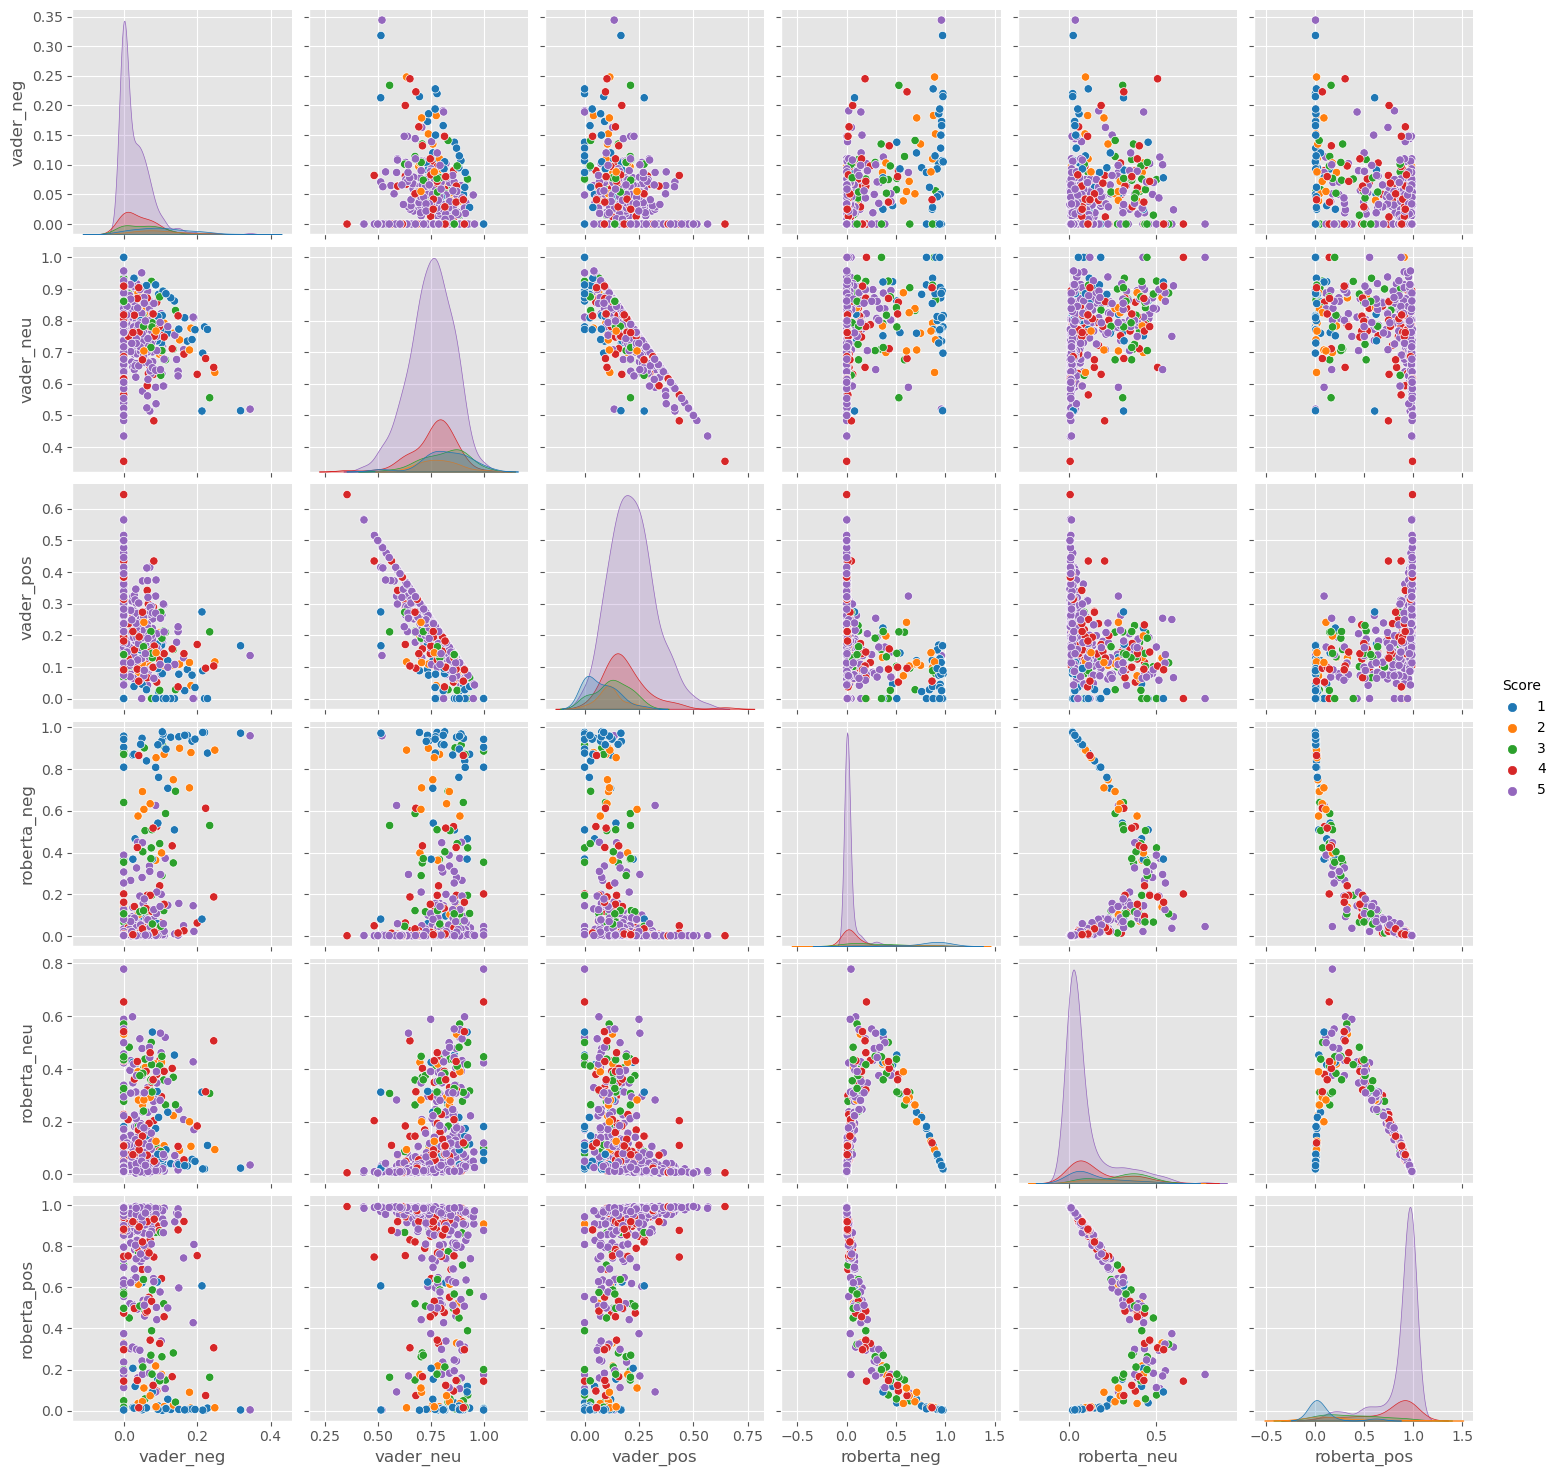

In [32]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

## STEP 4. REVIEW EXAMPLES 

Positive 1-Star and Negative 5-Star Reviews

Lets look at some examples where the model scoring and review score differ the most.

In [33]:
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.'

In [34]:
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

### NEGATIVE SENTIMENT 5-STAR REVIEW

In [35]:
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [36]:
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

## EXTRA : THE TRANSFORMERS PIPELINE

Quick & easy way to run sentiment predictions

In [47]:
# from transformers import pipeline
# - pipeline is a high-level utility in Hugging Face’s transformers library.
# - It abstracts away the details of loading tokenizers and models.
# - Just tell it what task you want to perform (e.g., "sentiment-analysis", "text-generation", "ner", etc.), and it handles the rest.

# sent_pipeline = pipeline("sentiment-analysis")
# - This line automatically downloads and loads a pre-trained sentiment model (usually distilbert-base-uncased-finetuned-sst-2-english, 
#   unless you specify another).
# - It returns a ready-to-use function that takes in text and outputs the sentiment.

In [37]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


In [38]:
sent_pipeline('I love sentiment analysis!')

[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

In [39]:
sent_pipeline('Make sure to like and subscribe!')

[{'label': 'POSITIVE', 'score': 0.9991742968559265}]

In [40]:
sent_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]